In [1]:
import sys
sys.path.append("../src")

In [2]:
from integrator import ComplexIntegrator
from context_manager import TriangleIntegrandEvaluator,TriangleIntegrandContext, spherical
from plot_util import get_contour
import oneloop_bridge
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
import pyvista as pv

from integrand_builder import IntegrandBuilder
from wrapped_eval import WrappedEvaluator

# do this to trigger the banner here so it doesn't get in the way later
oneloop_bridge.set_renormalization_scale(1.0)

import symbolica as sb
rng = sb.RandomNumberGenerator(42, 0)

########################################################################
#                                                                      #
#                        You are using OneLOop                         #
#                                                                      #
# for the evaluation of 1-loop scalar 1-, 2-, 3- and 4-point functions #
#                                                                      #
# author: Andreas van Hameren <hamerenREMOVETHIS@ifj.edu.pl>           #
#   date: 2024-11-23                                                   #
#                                                                      #
# Please cite                                                          #
#    A. van Hameren,                                                   #
#      Comput.Phys.Commun. 182 (2011) 2427-2438, arXiv:1007.4716       #
#    A. van Hameren, C.G. Papadopoulos and R. Pittau,                  #
#      JHEP 0909:106,2009, arXiv:0903.4665         

In [3]:
ctx = TriangleIntegrandContext()

ib = IntegrandBuilder()
ib.check_singularities_per_sample = False
ib.center_counterterm_region_at_origin = False
ib.smooth_mask = True

ctx.subtraction_width = 10
ctx.mask_width = 10

full_integrand = TriangleIntegrandEvaluator(WrappedEvaluator(ib.combined_result(), ib.get_args(), 'full_integrand'),ctx)

e_12 = TriangleIntegrandEvaluator(WrappedEvaluator(ib.e_surf(0,1, ib.k), ib.get_args(), 'e_12'),ctx)
e_23 = TriangleIntegrandEvaluator(WrappedEvaluator(ib.e_surf(1,2, ib.k), ib.get_args(), 'e_23'),ctx)
e_13 = TriangleIntegrandEvaluator(WrappedEvaluator(ib.e_surf(0,2, ib.k), ib.get_args(), 'e_13'),ctx)

Compiling evaluator: "full_integrand"
Done!
Compiling evaluator: "e_12"
Done!
Compiling evaluator: "e_23"
Done!
Compiling evaluator: "e_13"
Done!


In [4]:
AT = 201.904892335

ctx.set_anomalous_configuration(AT+3)
ctx.origin = np.array([0, 0, 0, 0])
plotter = pv.Plotter()
lims = (-100,100)

plotter.add_mesh(
    get_contour(lims, lims, lims, e_12.eval),
    color="cyan",
    smooth_shading=True,
)
plotter.add_mesh(
    get_contour(lims, lims, lims, e_13.eval),
    color="red",
    smooth_shading=True,
)
plotter.view_vector([1, 0, 0.1])
plotter.show_grid()
plotter.show(screenshot='../images/anomalous/above_threshold.png')

ctx.set_anomalous_configuration(AT-3)
ctx.origin = np.array([0, 0, 0, 0])

plotter = pv.Plotter()

plotter.add_mesh(
    get_contour(lims, lims, lims, e_12.eval),
    color="cyan",
    smooth_shading=True,
)
plotter.add_mesh(
    get_contour(lims, lims, lims, e_13.eval),
    color="red",
    smooth_shading=True,
)
plotter.view_vector([1, 0, 0.1])
plotter.show_grid()
plotter.show(screenshot='../images/anomalous/below_threshold.png')

Widget(value='<iframe src="http://localhost:32997/index.html?ui=P_0x7e5e8519f8f0_0&reconnect=auto" class="pyvi…

Widget(value='<iframe src="http://localhost:32997/index.html?ui=P_0x7e5e6327c4d0_1&reconnect=auto" class="pyvi…

In [5]:
ctx.set_anomalous_configuration(AT+0.5)
plotter = pv.Plotter()
lims = (-10,10)

plotter.add_mesh(
    get_contour(lims, lims, lims, e_12.eval),
    color="cyan",
    smooth_shading=True,
)
plotter.add_mesh(
    get_contour(lims, lims, lims, e_13.eval),
    color="red",
    smooth_shading=True,
)
plotter.view_vector([1, 0, 0.1])
plotter.show_grid()
plotter.show(screenshot='../images/anomalous/above_threshold_zoomed.png')

ctx.set_anomalous_configuration(AT)
plotter = pv.Plotter()
lims = (-10,10)

plotter.add_mesh(
    pv.Sphere(center = [0,0,0], radius = 0.4)
)

plotter.add_mesh(
    get_contour(lims, lims, lims, e_12.eval),
    color="cyan",
    smooth_shading=True,
)
plotter.add_mesh(
    get_contour(lims, lims, lims, e_13.eval),
    color="red",
    smooth_shading=True,
)
plotter.view_vector([1, 0, 0])
plotter.show_grid()
plotter.show(screenshot='../images/anomalous/on_threshold_zoomed.png')

ctx.set_anomalous_configuration(AT-0.5)

plotter = pv.Plotter()
plotter.add_mesh(
    pv.Sphere(center = [0,0,0], radius = 0.4)
)
plotter.add_mesh(
    get_contour(lims, lims, lims, e_12.eval),
    color="cyan",
    smooth_shading=True,
)
plotter.add_mesh(
    get_contour(lims, lims, lims, e_13.eval),
    color="red",
    smooth_shading=True,
)
plotter.view_vector([1, 0, 0.1])
plotter.show_grid()
plotter.show(screenshot='../images/anomalous/below_threshold_zoomed.png')

Widget(value='<iframe src="http://localhost:32997/index.html?ui=P_0x7e5e632142f0_2&reconnect=auto" class="pyvi…

Widget(value='<iframe src="http://localhost:32997/index.html?ui=P_0x7e5e87264560_3&reconnect=auto" class="pyvi…

Widget(value='<iframe src="http://localhost:32997/index.html?ui=P_0x7e5e9514ee10_4&reconnect=auto" class="pyvi…

In [6]:
def integrate_over_p2(p2s, triangle, epochs = 50, iters = 1000):
    results = []
    real_err = []
    imag_err = []
    convergence = []
    for p2 in tqdm(p2s):
        ctx.set_anomalous_configuration(p2 = p2)
        ci = ComplexIntegrator(3)
        result = ci.integrate(triangle.eval, spherical, epochs, iters, rng)
        results.append(result.real_avg + 1j*result.imag_avg)
        real_err.append(result.real_err)
        imag_err.append(result.imag_err)
        convergence.append(result.cv())
        
    return np.array(results), np.array(real_err), np.array(imag_err), np.array(convergence)

def reference_over_p2(p2s):
    ref = []
    for p2 in p2s:
        ctx.set_anomalous_configuration(p2 = p2)
        ref.append(ctx.get_reference())
        
    return np.array(ref)

<Figure size 2000x1000 with 0 Axes>

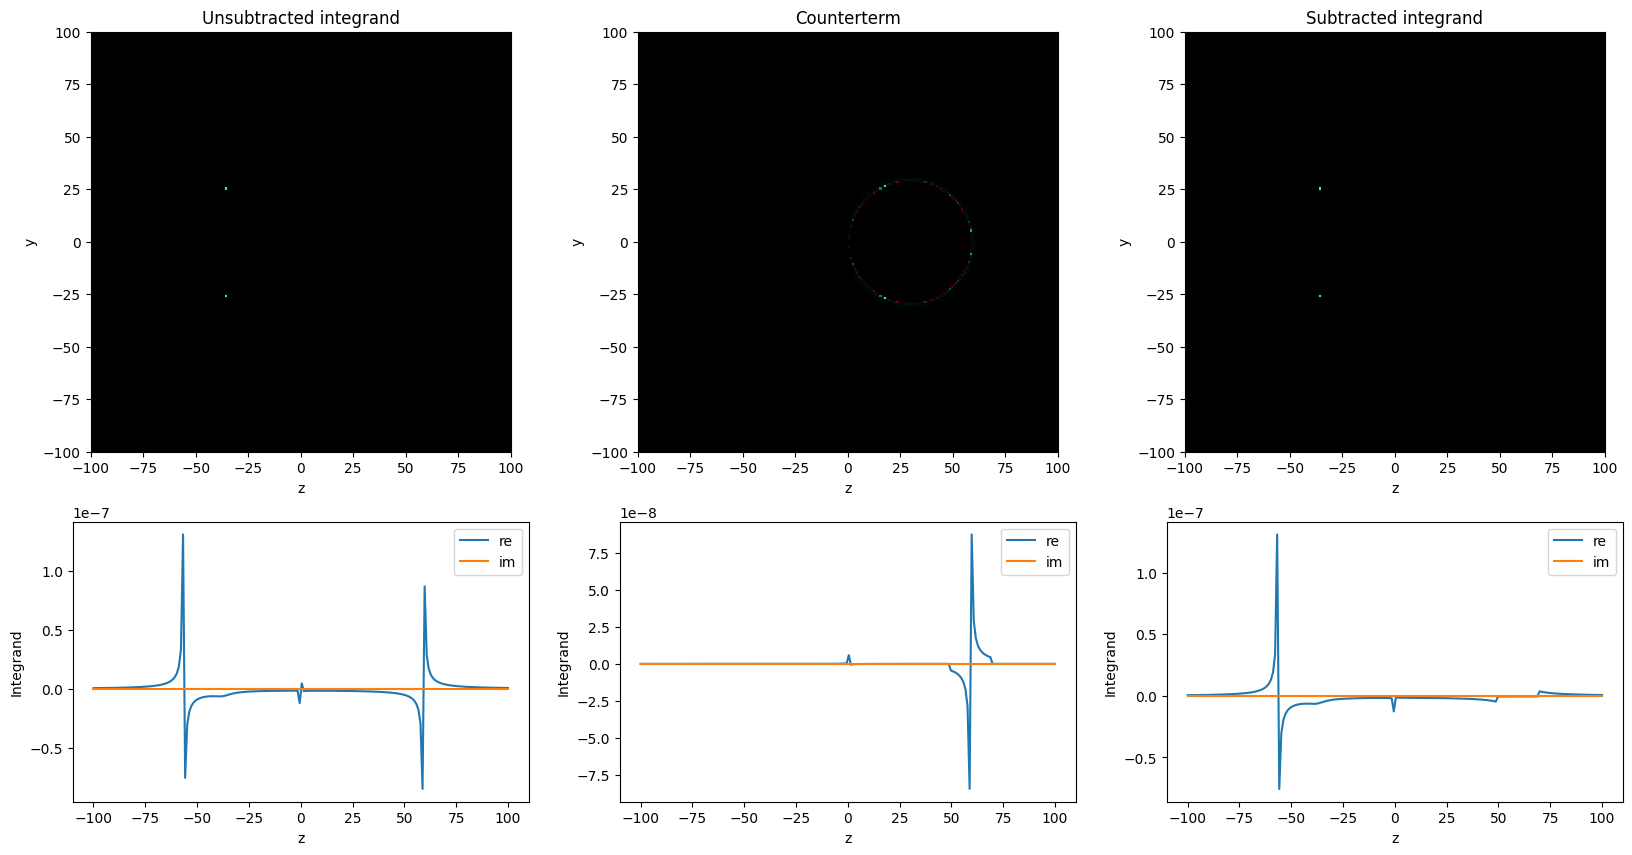

In [7]:


full_integrand.plot_threshold_subtraction((-100, 100), (-100, 100), x_axis=2)

In [8]:
sample_p2 = np.linspace(170,210,20)
reference_p2 = np.linspace(170,210,200)

ctx.combined_integrand()
combined_res = integrate_over_p2(sample_p2, full_integrand)

ref = reference_over_p2(reference_p2)

  0%|          | 0/20 [00:00<?, ?it/s]

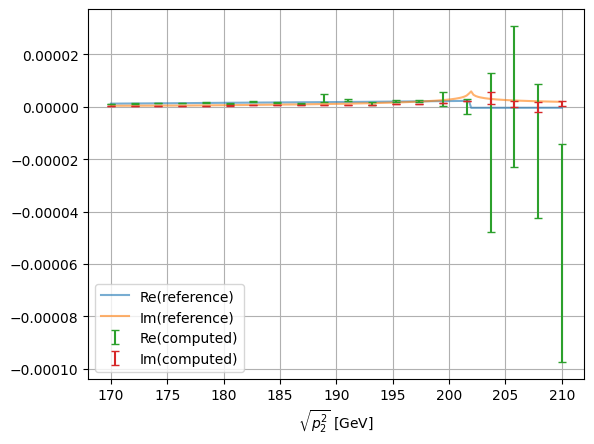

In [9]:
plt.plot(reference_p2, ref.real, label="Re(reference)", alpha = 0.6)
plt.plot(reference_p2, ref.imag, label="Im(reference)", alpha = 0.6)
plt.errorbar(
    sample_p2,
    combined_res[0].real,
    combined_res[1],
    ls="",
    capsize=3,
    label="Re(computed)",
)
plt.errorbar(
    sample_p2,
    combined_res[0].imag,
    combined_res[2],
    ls="",
    capsize=3,
    label="Im(computed)",
)
plt.xlabel("$\\sqrt{p_2^2}$ [GeV]")
plt.grid(True)
plt.legend()
plt.savefig(f"../images/anomalous/integrated.png", dpi=300)
plt.show()

In [ ]:
d = 0.0002
sample_p2 = np.linspace(AT-d,AT+d,20)
reference_p2 = np.linspace(AT-d,AT+d,200)

ctx.combined_integrand()
combined_res = integrate_over_p2(sample_p2, full_integrand)

ref = reference_over_p2(reference_p2)

  0%|          | 0/20 [00:00<?, ?it/s]

KeyboardInterrupt: 

: 

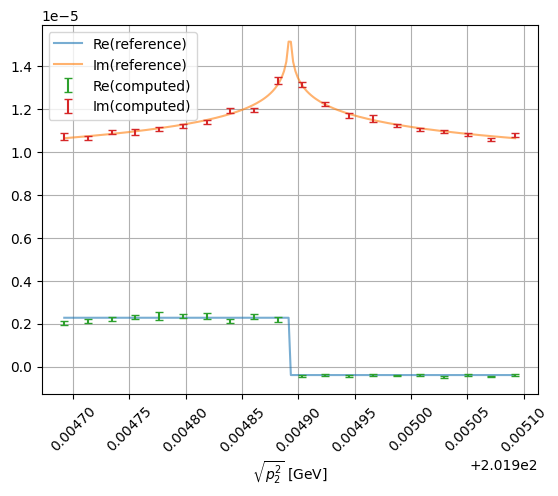

In [ ]:
plt.plot(reference_p2, ref.real, label="Re(reference)", alpha = 0.6)
plt.plot(reference_p2, ref.imag, label="Im(reference)", alpha = 0.6)
plt.errorbar(
    sample_p2,
    combined_res[0].real,
    combined_res[1],
    ls="",
    capsize=3,
    label="Re(computed)",
)
plt.errorbar(
    sample_p2,
    combined_res[0].imag,
    combined_res[2],
    ls="",
    capsize=3,
    label="Im(computed)",
)
plt.grid(True)
plt.legend()
plt.xlabel("$\\sqrt{p_2^2}$ [GeV]")
plt.savefig(f"../images/anomalous/integrated_zoomed.png", dpi=300)
plt.xticks(rotation=45)
plt.show()